In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from itertools import product

import seaborn as sns
# from run_exp import run_exp, run_exp_with_trans
import os
import re
from collections import Counter
from scipy.stats import chisquare
import matplotlib.pyplot as plt

from icl.tasks import DyckPathTask, DyckBayes
from icl.config import *
from icl.tasks.utils.dyck_utils import *
from icl.models import Transformer
import icl.utils.notebook_utils as nu
from icl.utils.train import *
from icl.figures.head_view import *
import icl.figures.plot as plot
from icl.figures.ood_plots import *

torch.set_printoptions(precision=3, sci_mode=False)

%load_ext autoreload
%autoreload 2

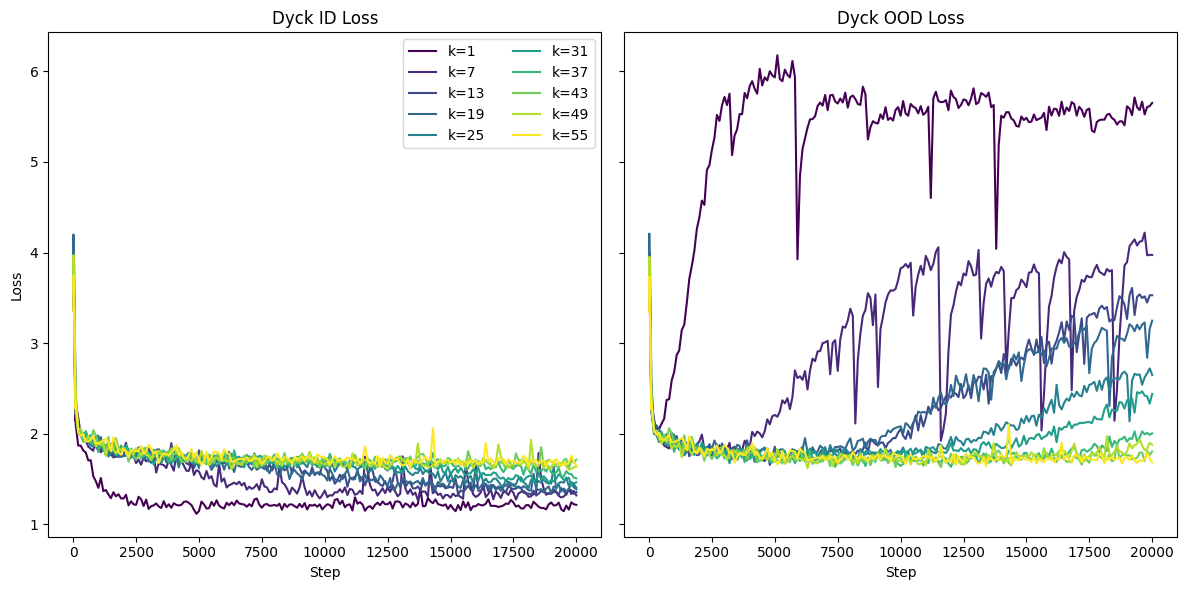

In [41]:
get_ood_plot()

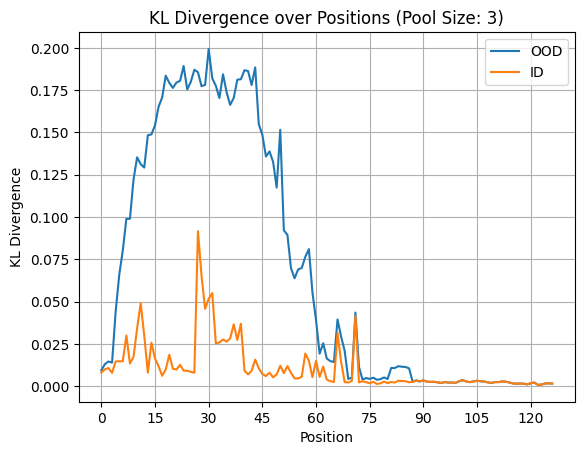

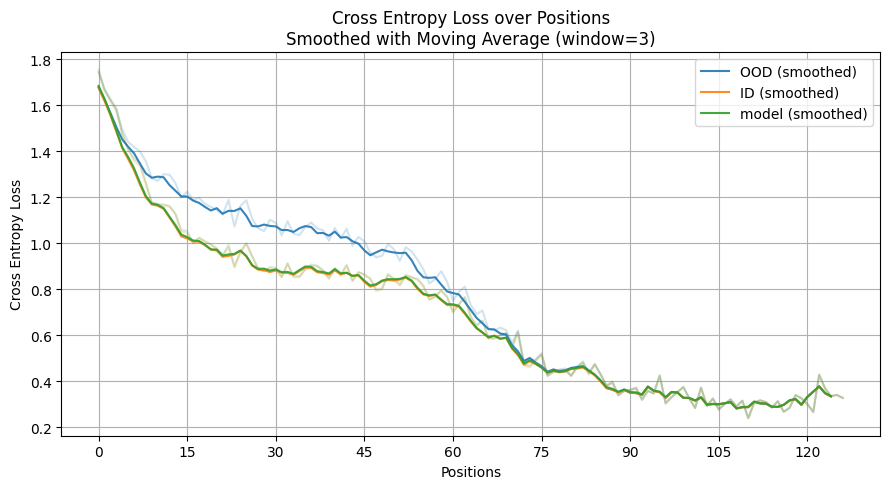

In [3]:
model, sampler, config, log_data = get_result(3)
get_and_plot_kl(config, sampler, model, masked=False, mode="eval", pos=150)
get_and_plot_ces(config, sampler, model, masked=False, mode="eval", pos=150)

In [4]:
for k in trange(1, 10):
    config = get_config()
    config.task.total_trans = k
    model = Transformer(config)
    model = model.to(config.device)
    
    _ = train_model_with_plot(model, config, show=False)

  0%|          | 0/9 [00:00<?, ?it/s]

Experiment directory:  results\dyck\train_d13fa8053f5d4ad48d919467efb1f073


wandb: Currently logged in as: hyan84 (hyan84-university-of-wisconsin-madison) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loss plots saved at results\dyck\train_d13fa8053f5d4ad48d919467efb1f073\plots
results\dyck\train_d13fa8053f5d4ad48d919467efb1f073\plots\loss.png
Experiment directory:  results\dyck\train_135ae60d569f45db93c1c04d316bf1ef


eval/IDAcc,▁▄▅▇▆▇▇▆▅▆▇▆█▆▅█▅▆▇▆▅▇▇▆▆▆▅▅▅▅▆▆▆▇▆▆▆▇▆▆
eval/IDLoss,█▄▃▁▁▁▂▁▁▁▁▂▂▂▁▂▁▁▂▁▁▂▂▁▁▁▂▁▁▂▁▁▁▂▁▂▁▂▁▁
eval/OODAcc,▁▁▇▃▆▃▃▃▂▄▄▇▃▅▅▅▂▆▆▅▆▅▆▅▇▄▆▅█▆▄▅█▅▆▄▄▆▂▅
eval/OODLoss,▃▅▄▄▅▄▄▄▄▄▄▄▆▆▇▅▇▇▇█▆████▅▅▆▇█▇▇██▆▇▇▁▃▅
eval/loss,█▃▂▂▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/IDAcc,0.52412
eval/IDLoss,1.21316
eval/OODAcc,0.27461
eval/OODLoss,4.70934


...

Loss plots saved at results\dyck\train_f6a289480b8d8abe505407b1949cd412\plots
results\dyck\train_f6a289480b8d8abe505407b1949cd412\plots\loss.png
Experiment directory:  results\dyck\train_40a0cb2dd99780282098558afcb3607f


eval/IDAcc,▁▂▂▃▃▃▅▃▄▄▇▇▇▆▂▆█▆▆▅▆▆▇▆▆█▇▅▇▇▆▇▆▅▆█▅▇▇█
eval/IDLoss,█▆▄▄▄▃▃▃▂▄▂▂▂▂▂▅▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/OODAcc,▃▁▁▃▄▅▄▄▅▆▅▇▇▆▆▅▇▇▅▅▆▅▅▆▇█▄▇▇▅▅▆▆▅▇▅▅▅▆█
eval/OODLoss,▄▁▁▁▁▁▁▂▁▁▃▃▃▃▄▅▅▆▆▆▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆█▆
eval/loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▃▃▃▄▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▂▂▂▃▂▂▂▂▂▁▂▂▂▂▂▂▂▂
train/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/IDAcc,0.34785
eval/IDLoss,1.31542
eval/OODAcc,0.21094
eval/OODLoss,4.44188


Loss plots saved at results\dyck\train_40a0cb2dd99780282098558afcb3607f\plots
results\dyck\train_40a0cb2dd99780282098558afcb3607f\plots\loss.png
Experiment directory:  results\dyck\train_fc28377e22f51ad50ca893f94ef7f67e


eval/IDAcc,▅▅▄▅▅▆▄▅▄▆▄▆▄▄▄▅▆▇▆▆▇▆▇▇▅▇▃▅▇▅▁▅█▆▅▇▆▆▇▇
eval/IDLoss,▆▅▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▂▁▂▁▁▂▁▂▁▅▂▁▁▁█▁▁▁▁▁▁▁
eval/OODAcc,▄▄█▆▆▃▂▁▄▃▃▅▅▆▃▃▄▄▅▃▄▃▅▆▄▅▂▃▁▇▆▃▆▄▅▄▅▄▄▅
eval/OODLoss,▃▃▁▁▁▁▁▃▄▄▆▆▅▆▅▇█▇▇██▅▆▇█▇███▁▇▇▇████▁▂▇
eval/loss,█▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁
train/loss,█▄▄▄▄▄▄▃▄▄▄▃▄▄▄▃▂▃▂▂▂▂▅▂▂▂▂▂▂▂▃▂▃▁▂▂▃▃▂▁
train/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/IDAcc,0.2457
eval/IDLoss,1.3011
eval/OODAcc,0.19844
eval/OODLoss,3.95292


Loss plots saved at results\dyck\train_fc28377e22f51ad50ca893f94ef7f67e\plots
results\dyck\train_fc28377e22f51ad50ca893f94ef7f67e\plots\loss.png


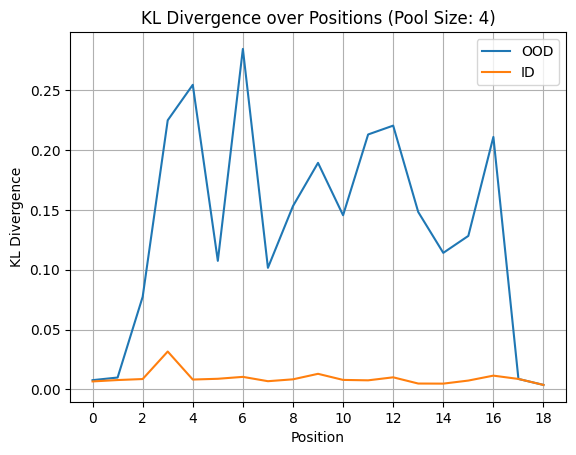

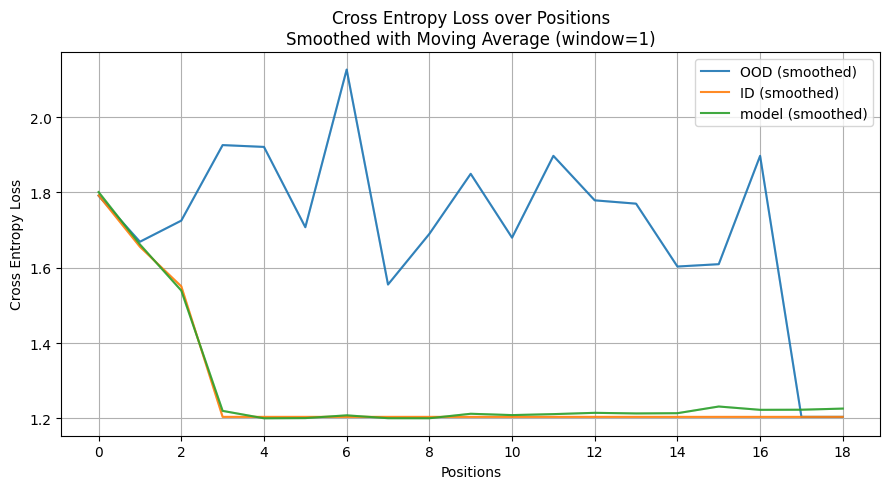

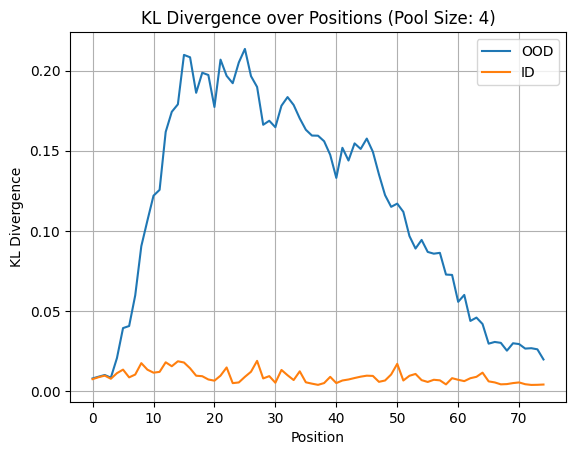

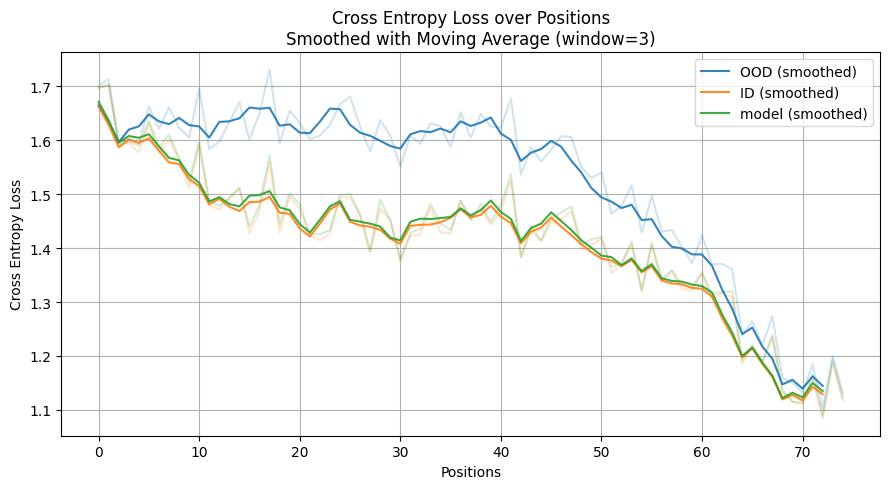

In [5]:
model, sampler, config, log_data = get_result(4)
dmask = get_dyck_mask(config, config.device)
get_and_plot_kl(config, sampler, model, masked=True, mode="eval", dyck_mask=None, pos=75)
get_and_plot_ces(config, sampler, model, masked=True, mode="eval", dyck_mask=None, pos=75)
get_and_plot_kl(config, sampler, model, masked=False, mode="eval", dyck_mask=None, pos=75)
get_and_plot_ces(config, sampler, model, masked=False, mode="eval", dyck_mask=None, pos=75)

In [43]:
injected_model = find_task_vector_with_baseline(
    model,
    sampler,
    config,
    task_idx=0,
    l0=0,
    num_epochs=3000,
    lr=1,
    optimizer_name="adamw"
)

[Task 0], Initial Loss Without Injection: 4.661147
[Task 0] Epoch 0, Loss: 3.345438 (Baseline: 1.238744)
[Task 0] Epoch 2, Loss: 3.061894 (Baseline: 1.238744)
[Task 0] Epoch 4, Loss: 3.421889 (Baseline: 1.238744)
[Task 0] Epoch 6, Loss: 3.840465 (Baseline: 1.238744)
[Task 0] Epoch 8, Loss: 3.703061 (Baseline: 1.238744)
[Task 0] Epoch 10, Loss: 3.507260 (Baseline: 1.238744)
[Task 0] Epoch 12, Loss: 3.267172 (Baseline: 1.238744)
[Task 0] Epoch 14, Loss: 3.074534 (Baseline: 1.238744)
[Task 0] Epoch 16, Loss: 3.011734 (Baseline: 1.238744)
[Task 0] Epoch 18, Loss: 2.950067 (Baseline: 1.238744)
[Task 0] Epoch 20, Loss: 2.928241 (Baseline: 1.238744)
[Task 0] Epoch 22, Loss: 2.722213 (Baseline: 1.238744)
[Task 0] Epoch 24, Loss: 2.596462 (Baseline: 1.238744)
[Task 0] Epoch 26, Loss: 2.592523 (Baseline: 1.238744)
[Task 0] Epoch 28, Loss: 2.505659 (Baseline: 1.238744)
[Task 0] Epoch 30, Loss: 2.524889 (Baseline: 1.238744)
[Task 0] Epoch 32, Loss: 2.481339 (Baseline: 1.238744)
[Task 0] Epoch 34, 

In [70]:
generated = batch_generate_tokens(model, config, sampler, 5, max_new_tokens=75, temperature=1.0)
subseq = extract_subsequences(generated, [config.vocab_size-3, config.vocab_size-2], config.task.dyck_length*2)
inds, counts = match_subsequences_to_task_pool_with_counts(sampler.task_pool, subseq)

In [11]:
layer = 1
task_vecs, task_batch_vars, generated_samples = get_task_vec_and_inject_bos(config, sampler, model, layer, None)
subseq = extract_subsequences(generated_samples[1], 
                              [config.vocab_size-3, config.vocab_size-2], config.task.dyck_length*2)
inds, counts = match_subsequences_to_task_pool_with_counts(sampler.task_pool, subseq)

TDNV: tensor(-1.217)


In [13]:
task_vecs

tensor([[    -0.266,      0.064,     -1.945,     -1.484,      0.816,     -1.376,
             -0.362,     -0.103,     -0.330,     -1.225,      1.034,      2.676,
             -0.234,     -0.201,     -0.287,     -0.716,     -1.100,      0.928,
             -0.331,     -0.000,     -0.114,      2.376,      1.409,      0.452,
              0.292,      1.031,      0.281,     -0.341,      0.605,     -0.101,
             -0.416,      0.060,     -0.867,     -1.425,      0.383,     -0.383,
              0.840,     -0.941,      0.182,     -0.559,      2.097,      0.631,
              1.336,     -0.256,     -0.113,     -1.291,     -2.282,      0.218,
             -0.313,     -1.028,     -0.528,     -1.336,      0.630,      1.819,
              0.356,     -1.400,     -0.811,     -0.872,      0.573,     -0.750,
              0.592,      1.716,     -1.269,      0.488],
        [    -0.266,      0.064,     -1.945,     -1.484,      0.816,     -1.376,
             -0.362,     -0.103,     -0.330,     -1

### Collapsed Representation

In [459]:
model, sampler, config, log_data = get_result(6)
dmask = get_dyck_mask(config, config.device)

layer = 3
dpos = 13
tv_dist, kl_dist, last_acc, task_vecs, model_probs = get_task_vec_and_inject(config, sampler, model, 
                                                     dpos=dpos, layer=layer, dmask=dmask)
print(last_acc.mean())

TDNV: tensor(1.167)
tensor(0.191)


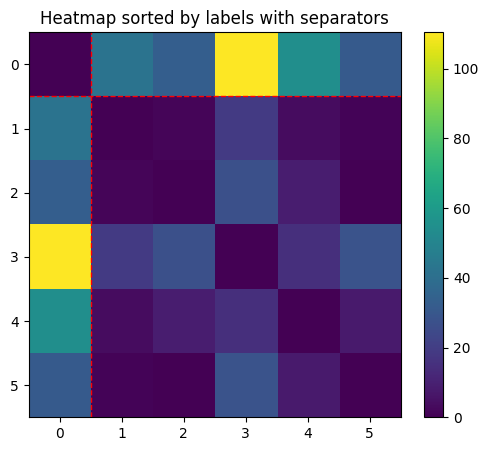

In [460]:
tnorm2 = task_vecs.norm(dim=-1, keepdim=True)**2
dist_mat = tnorm2 + tnorm2.T - 2*task_vecs @ task_vecs.T
labels = model_probs.argmax(dim=-1)
sort_idx = torch.argsort(labels).cpu()
sorted_labels = labels[sort_idx]
H_sorted = dist_mat[sort_idx, :][:, sort_idx]
boundaries = (sorted_labels[1:] != sorted_labels[:-1]).nonzero(as_tuple=False).flatten() + 0.5  # Add 0.5 for alignment

plt.figure(figsize=(6, 5))
plt.imshow(H_sorted.numpy(), aspect='auto', cmap='viridis')
for b in boundaries.cpu().numpy():
    plt.axhline(b, color='red', linestyle='--', linewidth=1)
    plt.axvline(b, color='red', linestyle='--', linewidth=1)
plt.colorbar()
plt.title("Heatmap sorted by labels with separators")
plt.show()

In [453]:
model, sampler, config, log_data = get_result(6)
dmask = get_dyck_mask(config, config.device)

layer = 5
dpos = 13
tv_dist, kl_dist, last_acc, task_vecs, model_probs = get_task_vec_and_inject(config, sampler, model, 
                                                     dpos=dpos, layer=layer, dmask=dmask)
print(last_acc.mean())

TDNV: tensor(21.294)
tensor(0.071)


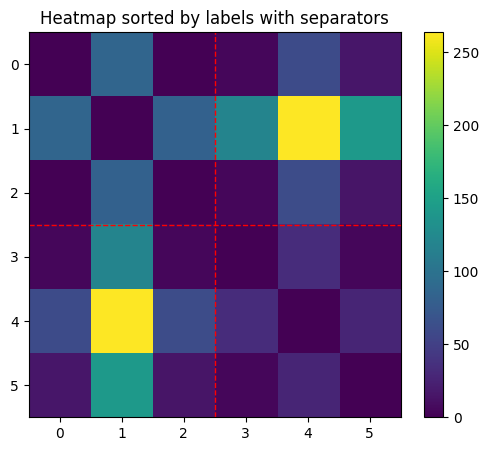

In [454]:
tnorm2 = task_vecs.norm(dim=-1, keepdim=True)**2
dist_mat = tnorm2 + tnorm2.T - 2*task_vecs @ task_vecs.T
labels = model_probs.argmax(dim=-1)
sort_idx = torch.argsort(labels).cpu()
sorted_labels = labels[sort_idx]
H_sorted = dist_mat[sort_idx, :][:, sort_idx]
boundaries = (sorted_labels[1:] != sorted_labels[:-1]).nonzero(as_tuple=False).flatten() + 0.5  # Add 0.5 for alignment

plt.figure(figsize=(6, 5))
plt.imshow(H_sorted.numpy(), aspect='auto', cmap='viridis')
for b in boundaries.cpu().numpy():
    plt.axhline(b, color='red', linestyle='--', linewidth=1)
    plt.axvline(b, color='red', linestyle='--', linewidth=1)
plt.colorbar()
plt.title("Heatmap sorted by labels with separators")
plt.show()

In [415]:
layer = 4
dpos = 13
tv_dist, kl_dist, last_acc, task_vecs = get_task_vec_and_inject(config, sampler, model, 
                                                     dpos=dpos, layer=layer, dmask=dmask)
print(last_acc.mean())

TDNV: tensor(1072.161)
tensor(0.026)


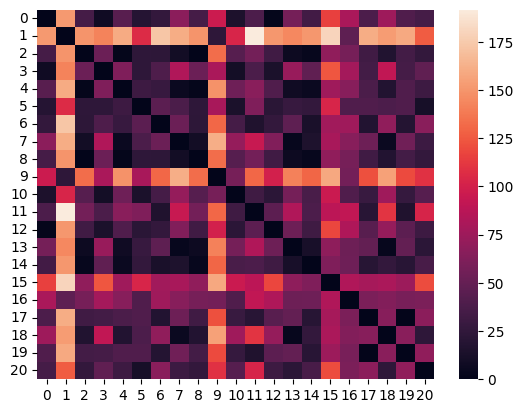

In [416]:
tnorm2 = task_vecs.norm(dim=-1, keepdim=True)**2
dist_mat = tnorm2 + tnorm2.T - 2*task_vecs @ task_vecs.T
labels = sampler.task_pool[:,dpos-1]
sort_idx = torch.argsort(labels).cpu()
sns.heatmap(dist_mat[sort_idx,:][:,sort_idx])
plt.show()

In [417]:
layer = 3
dpos = 13
tv_dist, kl_dist, last_acc, task_vecs = get_task_vec_and_inject(config, sampler, model, 
                                                     dpos=dpos, layer=layer, dmask=dmask)
print(last_acc.mean())

TDNV: tensor(10883.071)
tensor(0.161)


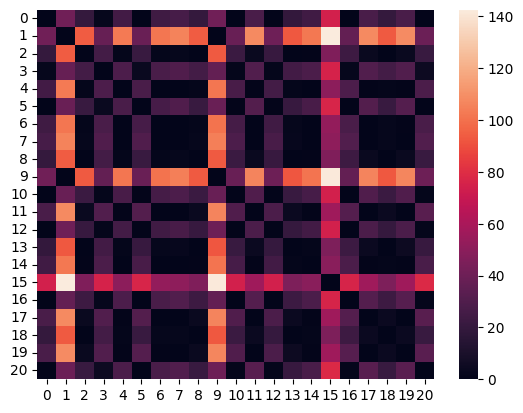

In [418]:
tnorm2 = task_vecs.norm(dim=-1, keepdim=True)**2
dist_mat = tnorm2 + tnorm2.T - 2*task_vecs @ task_vecs.T
labels = sampler.task_pool[:,dpos-1]
sort_idx = torch.argsort(labels).cpu()
sns.heatmap(dist_mat[sort_idx,:][:,sort_idx])
plt.show()